In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Insert warehouse name here
warehouse_name = "OE"

base = "~/Lucas_Systems_Capstone_Project"

# Load your processed data
df = pd.read_parquet(f"{base}/data/processed/oe_detailed.parquet")

# Filter for only Work Code 30
df = df[df["WorkCode"] == "30"]

# Drop missing rows for important variables
df = df.dropna(subset=['Weight', 'Cube', 'Level', 'Time_Delta_sec', 'Travel_Distance'])

In [6]:
# Feature lists
cols_with_dist = ['Weight', 'Cube', 'Level', 'Travel_Distance']
cols_without_dist = ['Weight', 'Cube', 'Level']
target = 'Time_Delta_sec'

In [7]:
# Define parameter grid
n_neighbors_list = [5, 10]
weights_list = ['uniform', 'distance']
distance_inclusion_list = [True, False]
results = []

In [8]:
# Evaluation loop

for k in n_neighbors_list:
    for w in weights_list:
        for include_dist in distance_inclusion_list:
            
            # Select features based on current iteration
            features = cols_with_dist if include_dist else cols_without_dist
            
            # Prepare data
            X = df[features]
            y = df[target]
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
            
            # Scale features
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            
            # Train model
            knn = KNeighborsRegressor(n_neighbors=k, weights=w)
            knn.fit(X_train_scaled, y_train)
            
            # Evaluate
            predictions = knn.predict(X_test_scaled)
            mae = mean_absolute_error(y_test, predictions)
            
            # Store results
            results.append({
                'mae': mae,
                'model': knn,
                'params': f"k={k}, weights={w}, dist={include_dist}",
                'X_test_scaled': X_test_scaled,
                'y_test': y_test
            })

In [9]:
# 1. Create the main DataFrame
df_results = pd.DataFrame(results)

# 2. Create a 'Summary' DataFrame for display
# This drops the objects (model, arrays) and keeps only the readable metrics
df_summary = df_results[['params', 'mae']].sort_values(by='mae')

# 3. Print it out nicely
print(df_summary.to_string(index=False))

# --- Why this is better ---
# If you try to print(df_results), you will see things like:
# KNeighborsRegressor(...) | [[0.1, 0.2...]] | [0.5, 0.1...]
# By creating df_summary, you get a clean table that looks like this:
#
#       params      mae
# k=10, weights=dist, dist=True  2.45
# k=5, weights=dist, dist=True   2.89

                            params       mae
  k=10, weights=uniform, dist=True 31.971696
 k=10, weights=distance, dist=True 32.093404
   k=5, weights=uniform, dist=True 32.987064
  k=5, weights=distance, dist=True 33.108634
 k=10, weights=uniform, dist=False 36.664610
k=10, weights=distance, dist=False 37.113330
  k=5, weights=uniform, dist=False 38.714177
 k=5, weights=distance, dist=False 38.926428


Top Model:
k=10, weights=uniform, dist=True
MAE: 31.9717


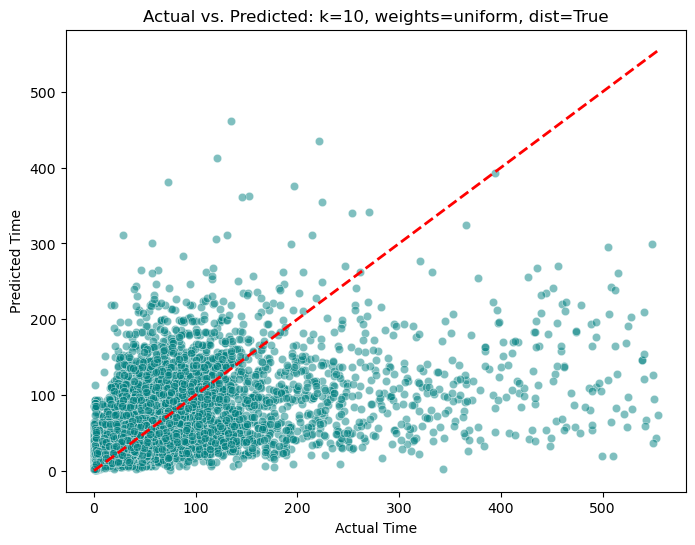

In [15]:
# Sort by MAE (ascending)
sorted_results = sorted(results, key=lambda x: x['mae'])
top_one = sorted_results[:1]

print("Top Model:")
for i, res in enumerate(top_one):
    print(f"{res['params']}\nMAE: {res['mae']:.4f}")

# Plot Top Model
for i, res in enumerate(top_one):
    y_pred = res['model'].predict(res['X_test_scaled'])
    
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=res['y_test'], y=y_pred, alpha=0.5, color='teal')
    plt.plot([res['y_test'].min(), res['y_test'].max()], [res['y_test'].min(), res['y_test'].max()], '--r', linewidth=2)
    plt.title(f'Actual vs. Predicted: {res["params"]}')
    plt.xlabel('Actual Time')
    plt.ylabel('Predicted Time')
    plt.show()

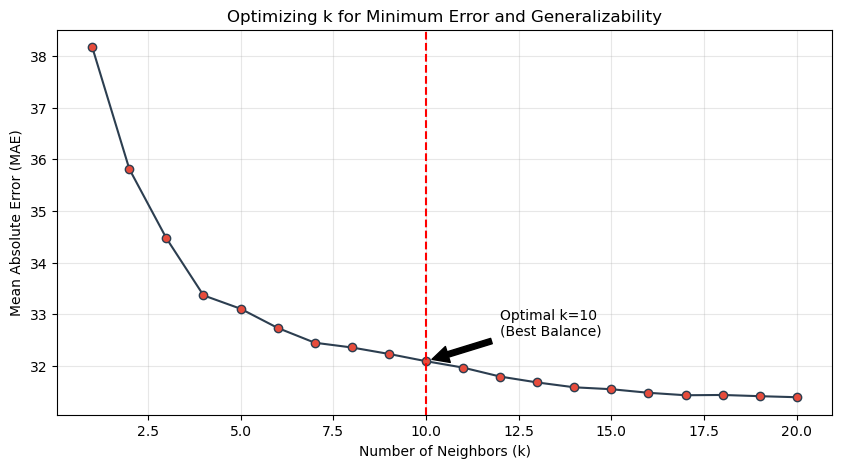

In [ ]:
# Generate MAE Scores for k=1 to 20
k_range = range(1, 21)
mae_scores = []

# Using the best features (e.g., with travel distance) from your previous run
X = df[cols_with_dist] 
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k, weights='distance')
    knn.fit(X_train_scaled, y_train)
    preds = knn.predict(X_test_scaled)
    mae_scores.append(mean_absolute_error(y_test, preds))

# Plot the Optimization Curve 
plt.figure(figsize=(10, 5))
plt.plot(k_range, mae_scores, marker='o', linestyle='-', color='#2c3e50', markerfacecolor='#e74c3c')

# Annotate the optimal point
plt.annotate('Optimal k=10\n(Best Balance)', xy=(10, mae_scores[9]), xytext=(12, mae_scores[9]+0.5),
             arrowprops=dict(facecolor='black', shrink=0.08))

plt.title('Optimizing k for Minimum Error and Generalizability')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Absolute Error (MAE)')
plt.axvline(x=10, color='red', linestyle='--')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Extract MAE filtered by weight='uniform'
def get_uniform_mae(k, dist, results):
    # Filter list for the specific combination with weight='uniform'
    matches = [r['mae'] for r in results if f"k={k}" in r['params'] 
               and f"dist={dist}" in r['params'] 
               and "weights=uniform" in r['params']]
    return matches[0] if matches else 0.0

# Extract MAE values
mae_5_dist = get_uniform_mae(5, True, results)
mae_5_nodist = get_uniform_mae(5, False, results)
mae_10_dist = get_uniform_mae(10, True, results)
mae_10_nodist = get_uniform_mae(10, False, results)

# Table
summary2 = pd.DataFrame(
    columns=['k', 'Distance Included', 'Distance Not Included'],
    data=[
        ['5', round(mae_5_dist, 2), round(mae_5_nodist, 2)],
        ['10', round(mae_10_dist, 2), round(mae_10_nodist, 2)]
    ]
)

# Results
print("Summary (Weights = Uniform):\n")
print(summary2.to_string(index=False))

Summary (Weights = Uniform):

 k  Distance Included  Distance Not Included
 5              32.99                  38.71
10              31.97                  36.66
